In [1]:
from sklearn.linear_model import Ridge , LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd


mercari_df= pd.read_csv('../data/mercari_train.tsv',sep='\t')
print(mercari_df.shape)
mercari_df.head(3)


(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


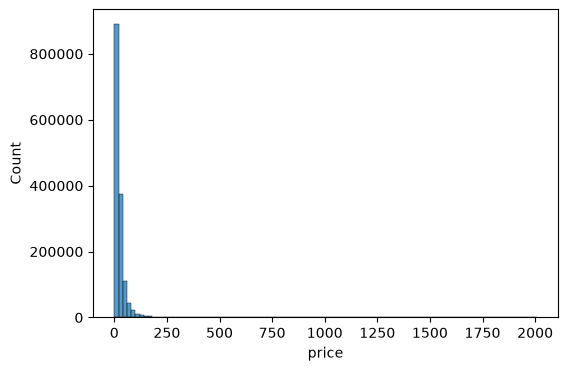

price
0.0         874
3.0       18703
4.0       16139
5.0       31502
5.5          33
          ...  
1999.0        1
2000.0        6
2004.0        1
2006.0        1
2009.0        1
Name: count, Length: 828, dtype: int64

In [2]:
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns

#원본 보관(백업용) 및 답 임시생성(그래프 생성용)
mercari_ori= mercari_df
y_labels = mercari_df['price']

plt.figure(figsize=(6,4))
sns.histplot(y_labels, bins=100)
plt.show()




mercari_df.value_counts('price').sort_index()

# y_labels 0처리 이후 다시 재조정예정


In [3]:
# 전처리전 체크
print(f'전처리 전 : {mercari_df.shape}')

# 가격이 0인 데이터 제거
mercari_df = mercari_df[mercari_df['price']>0]
print(f'0 제거 후 : {mercari_df.shape}')

# 가격이 2000이상인 데이터 제거
mercari_df = mercari_df[mercari_df['price']<2000]
print(f'2000이상 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)

print(f'train_id 제거 후 : {mercari_df.shape}')

전처리 전 : (1482535, 8)
0 제거 후 : (1481661, 8)
2000이상 제거 후 : (1481652, 8)
train_id 제거 후 : (1481603, 7)


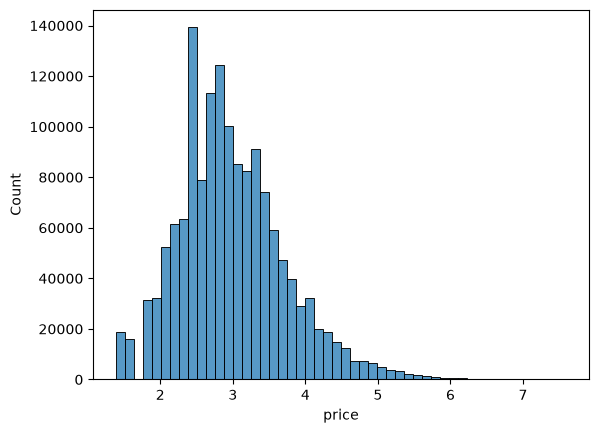

In [4]:
import numpy as np

y_labels = mercari_df['price']

mercari_df['price']= np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

In [5]:
# 'decription'만 텍스트 전처리(나머지는 알아서!)
# 모듈 불러오기
import pandas as pd
import re
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

#텍스트 클리닝(소문자/공백)
def text_cleaning(text):
    
    # 소문자로 변환
    text = text.lower()
    
    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 부정 표현
negative_words = {
    'no',
    'not',
    'nor',
    'never',
    'without'
}

# [rm] 마스킹 토큰이 클렌징 후 'rm'이라는 의미 없는 잔여 토큰으로 남는 것을 불용어로 추가 제거
stop_words = stop_words | {'rm'}

# 불용어 목록에서 부정 표현 제외
stop_words = stop_words - negative_words


In [6]:
mercari_df['item_description'].apply(type).value_counts()

item_description
<class 'str'>      1481597
<class 'float'>          6
Name: count, dtype: int64

In [7]:
#소문자 / 영문자/공백/여러개공백 처리 / 토크나이즈 함수

def preprocess_text(text):
     # 1. 소문자 / 영문자 / 공백 정리
    text = text_cleaning(text)

    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)

    # 3. 불용어 제거
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return tokens


def preprocess_description(text):
    # 1. 결측치 처리 + 문자열 변환
    if pd.isna(text):
        text = 'No description yet'
    

    # 2. 클렌징 + 토큰화 + 불용어 제거
    tokens = preprocess_text(text)

    # 3. 리스트 → 문자열
    text = ' '.join(tokens)

    return text




In [8]:
mercari_df['item_description'] = (
    mercari_df['item_description']
    .apply(preprocess_description)
)
# 클렌징 및 토큰화 후, 최종 확인
mercari_df['item_description'].head()

0                                   no description yet
1    keyboard great condition works like came box p...
2    adorable top hint lace key hole back pale pink...
3    new tags leather horses retail stand foot high...
4                    complete certificate authenticity
Name: item_description, dtype: str

In [9]:
#프로덕트 텍스트 새로 생성(name,brand_name, category_name) 함수 제작
def make_product_text(df):
    df['product_text'] = (
        df['name'].fillna('') + ' ' +
        df['brand_name'].fillna('') + ' ' +
        df['category_name'].fillna('').str.replace('/', ' ', regex=False)
    )

    df['product_text'] = (
        df['product_text']
        .apply(preprocess_text)
        .apply(lambda x: ' '.join(x))
    )

    return df

def fix_item_description(df):
    df[['item_description']=='no description yet'] = ' '
    df['item_description'] = (
    df['name'].fillna('') + ' ' +
    df['item_description'].fillna('')
    )
    
    return df

In [10]:
make_product_text(mercari_df)
fix_item_description(mercari_df)
mercari_df['product_text']

0          mlb cincinnati reds shirt size xl men tops shirts
1          razer blackwidow chroma keyboard razer electro...
2            ava viv blouse target women tops blouses blouse
3          leather horse statues home home cor home cor a...
4               24k gold plated rose women jewelry necklaces
                                 ...                        
1481598    free people inspired dress free people women d...
1481599    little mermaid handmade dress disney kids girl...
1481600    21 day fix containers eating plan sports outdo...
1481601    world markets lanterns home home cor home cor ...
1481602    brand new lux de ville wallet women women acce...
Name: product_text, Length: 1481603, dtype: str

In [11]:
#item_description에 이름 넣기
mercari_df[['item_description']=='not description yet'] = ' '
mercari_df['item_description'] = (
    mercari_df['name'].fillna('') + ' ' +
    mercari_df['item_description'].fillna('')
)

In [12]:
#단어와 길이도 한번 LGBM Feature로 넣어보기로

# # product_text 길이
# mercari_df['product_text_len'] = (
#     mercari_df['product_text'].str.len()
# )

# # product_text 단어 수
# mercari_df['product_text_word_count'] = (
#     mercari_df['product_text'].str.split().str.len()
# )

# # description 길이
# mercari_df['description_len'] = (
#     mercari_df['item_description'].str.len()
# )

# # description 단어 수
# mercari_df['description_word_count'] = (
#     mercari_df['item_description'].str.split().str.len()
# )

In [13]:
# mercari_df[[
#     'product_text_len',
#     'product_text_word_count',
#     'description_len',
#     'description_word_count'
# ]].describe()

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = (
    train_test_split(
        mercari_df[['product_text','item_description','item_condition_id','shipping',
                    # 'product_text_len','product_text_word_count','description_len','description_word_count']
        ]],
        y_labels,
        test_size=0.2,
        random_state=42
    )
)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 상품명 + 브랜드 + 카테고리
product_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=50000
)

# 상품 설명
description_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=50000
)

In [16]:
def tfidf_transform(
    X_train,
    X_valid,
    product_tfidf,
    description_tfidf
):
    # product_text
    X_train_product = product_tfidf.fit_transform(
        X_train['product_text']
    )
    X_valid_product = product_tfidf.transform(
        X_valid['product_text']
    )

    # item_description
    X_train_desc = description_tfidf.fit_transform(
        X_train['item_description']
    )
    X_valid_desc = description_tfidf.transform(
        X_valid['item_description']
    )

    return (
        X_train_product,
        X_valid_product,
        X_train_desc,
        X_valid_desc
    )

In [17]:
X_train_product, X_valid_product, X_train_desc, X_valid_desc = (
    tfidf_transform(
        X_train,
        X_valid,
        product_tfidf,
        description_tfidf
    )
)

In [18]:
from scipy.sparse import csr_matrix, hstack

X_train_num = csr_matrix(
    X_train[
        ['item_condition_id', 'shipping',
        #  'product_text_len',
        #  'product_text_word_count'
         ]
    ].values
)

X_valid_num = csr_matrix(
    X_valid[
        ['item_condition_id', 'shipping',
        #  'product_text_len',
        #  'product_text_word_count'
         ]
    ].values
)

In [19]:
X_train_final = hstack([
    X_train_product,
    X_train_desc,
    X_train_num
]).tocsr()

X_valid_final = hstack([
    X_valid_product,
    X_valid_desc,
    X_valid_num
]).tocsr()

In [20]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_squared_error
import numpy as np

lgbm = LGBMRegressor(
    objective='regression',
    n_estimators=6000,          # num_boost_round=2000 대응
    learning_rate=0.1,
    num_leaves=31,
    feature_fraction=0.8,       # 또는 colsample_bytree=0.8
    bagging_fraction=0.8,       # 또는 subsample=0.8
    bagging_freq=5,             # 또는 subsample_freq=5
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(
    X_train_final,
    y_train,

    eval_set=[
        (X_train_final, y_train),
        (X_valid_final, y_valid)
    ],

    eval_metric='rmse',

    callbacks=[
        early_stopping(
            stopping_rounds=50
        ),
        log_evaluation(
            period=100
        )
    ]
)

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 0.527253	training's l2: 0.277996	valid_1's rmse: 0.529501	valid_1's l2: 0.280371
[200]	training's rmse: 0.499936	training's l2: 0.249936	valid_1's rmse: 0.503481	valid_1's l2: 0.253493
[300]	training's rmse: 0.485507	training's l2: 0.235717	valid_1's rmse: 0.490138	valid_1's l2: 0.240235
[400]	training's rmse: 0.475641	training's l2: 0.226234	valid_1's rmse: 0.481171	valid_1's l2: 0.231526
[500]	training's rmse: 0.468199	training's l2: 0.21921	valid_1's rmse: 0.474659	valid_1's l2: 0.225301
[600]	training's rmse: 0.462214	training's l2: 0.213642	valid_1's rmse: 0.469563	valid_1's l2: 0.22049
[700]	training's rmse: 0.457218	training's l2: 0.209048	valid_1's rmse: 0.465567	valid_1's l2: 0.216753
[800]	training's rmse: 0.452822	training's l2: 0.205048	valid_1's rmse: 0.462036	valid_1's l2: 0.213477
[900]	training's rmse: 0.448988	training's l2: 0.20159	valid_1's rmse: 0.459053	valid_1's l2: 0.21073
[1000]	

,n_estimators,6000
,objective,'regression'
,random_state,42
,n_jobs,-1
,feature_fraction,0.8
,bagging_fraction,0.8
,bagging_freq,5
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [21]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_squared_error
import numpy as np

lgbm = LGBMRegressor(
    objective='regression',
    n_estimators=4000,       # 2000 → 4000
    learning_rate=0.1,
    num_leaves=31,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm.fit(
    X_train_final,
    y_train,

    eval_set=[
        (X_train_final, y_train),
        (X_valid_final, y_valid)
    ],

    eval_metric='rmse',

    callbacks=[
        early_stopping(
            stopping_rounds=50
        ),
        log_evaluation(
            period=100
        )
    ]
)

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 0.527253	training's l2: 0.277996	valid_1's rmse: 0.529501	valid_1's l2: 0.280371
[200]	training's rmse: 0.499936	training's l2: 0.249936	valid_1's rmse: 0.503481	valid_1's l2: 0.253493
[300]	training's rmse: 0.485507	training's l2: 0.235717	valid_1's rmse: 0.490138	valid_1's l2: 0.240235
[400]	training's rmse: 0.475641	training's l2: 0.226234	valid_1's rmse: 0.481171	valid_1's l2: 0.231526
[500]	training's rmse: 0.468199	training's l2: 0.21921	valid_1's rmse: 0.474659	valid_1's l2: 0.225301
[600]	training's rmse: 0.462214	training's l2: 0.213642	valid_1's rmse: 0.469563	valid_1's l2: 0.22049
[700]	training's rmse: 0.457218	training's l2: 0.209048	valid_1's rmse: 0.465567	valid_1's l2: 0.216753
[800]	training's rmse: 0.452822	training's l2: 0.205048	valid_1's rmse: 0.462036	valid_1's l2: 0.213477
[900]	training's rmse: 0.448988	training's l2: 0.20159	valid_1's rmse: 0.459053	valid_1's l2: 0.21073
[1000]	

,n_estimators,4000
,objective,'regression'
,random_state,42
,n_jobs,-1
,feature_fraction,0.8
,bagging_fraction,0.8
,bagging_freq,5
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [22]:
import pandas as pd
import numpy as np

def get_lgbm_feature_importance(
    model,
    product_tfidf,
    description_tfidf,
    num_features,
    top_n=30,
    importance_type='gain'
):
    # 1. TF-IDF feature 이름
    product_features = [
        'product_' + word
        for word in product_tfidf.get_feature_names_out()
    ]

    desc_features = [
        'desc_' + word
        for word in description_tfidf.get_feature_names_out()
    ]

    # 2. 최종 feature 이름 순서
    feature_names = (
        product_features +
        desc_features +
        num_features
    )

    # 3. LightGBM importance 추출
    importance = model.booster_.feature_importance(
        importance_type=importance_type
    )

    # 4. 길이 체크
    if len(feature_names) != len(importance):
        raise ValueError(
            f'Feature 개수 불일치: '
            f'feature_names={len(feature_names)}, '
            f'importance={len(importance)}'
        )

    # 5. DataFrame 생성
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    })

    importance_df = (
        importance_df
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )

    return importance_df.head(top_n)

In [23]:
import numpy as np
import pandas as pd

product_features = [
    'product_' + x
    for x in product_tfidf.get_feature_names_out()
]

desc_features = [
    'desc_' + x
    for x in description_tfidf.get_feature_names_out()
]

num_features = [
    'item_condition_id',
    'shipping'
]

feature_names = (
    product_features
    + desc_features
    + num_features
)